<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>



#### Import the required libraries we need for the lab.


In [2]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [52]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#### Read the dataset in the csv file from the URL


In [4]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [5]:
boston_df=pd.read_csv(boston_url)

#### Add your code below following the instructions given in the course to complete the peer graded assignment


In [6]:
display(boston_df)

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,9.67,22.4
502,502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,9.08,20.6
503,503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,5.64,23.9
504,504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,6.48,22.0


<AxesSubplot:ylabel='MEDV'>

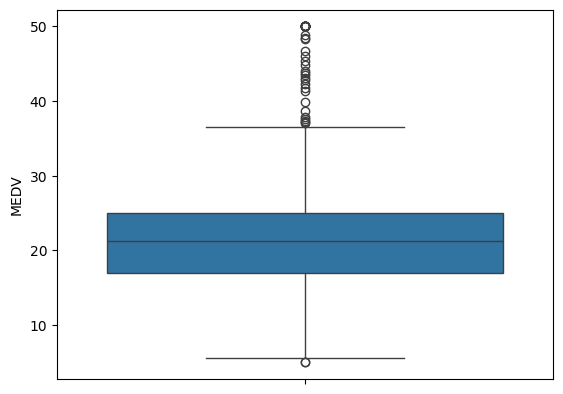

In [13]:
sns.boxplot( y="MEDV", data=boston_df)

In [8]:

boston_df.to_csv("X:\\Abinaya\\Output.csv", index=False)
print("CSV file saved successfully!")



CSV file saved successfully!


In [9]:
boston_df.to_csv("C:\\Users\\YourUsername\\Desktop\\Output.csv", index=False)

In [10]:
print(boston_df.head())

   Unnamed: 0     CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  \
0           0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0   
1           1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0   
2           2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0   
3           3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0   
4           4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0   

     TAX  PTRATIO  LSTAT  MEDV  
0  296.0     15.3   4.98  24.0  
1  242.0     17.8   9.14  21.6  
2  242.0     17.8   4.03  34.7  
3  222.0     18.7   2.94  33.4  
4  222.0     18.7   5.33  36.2  


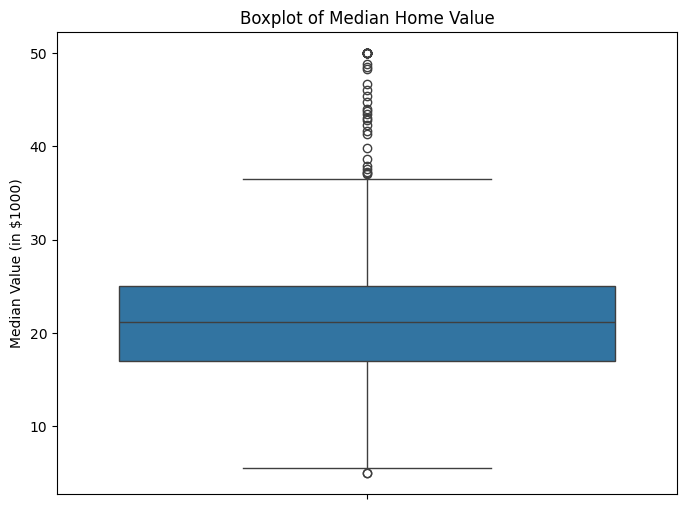

In [19]:

pyplot.figure(figsize=(8,6))
sns.boxplot(y=boston_df['MEDV'])
pyplot.title('Boxplot of Median Home Value')
pyplot.ylabel('Median Value (in $1000)')
pyplot.show()

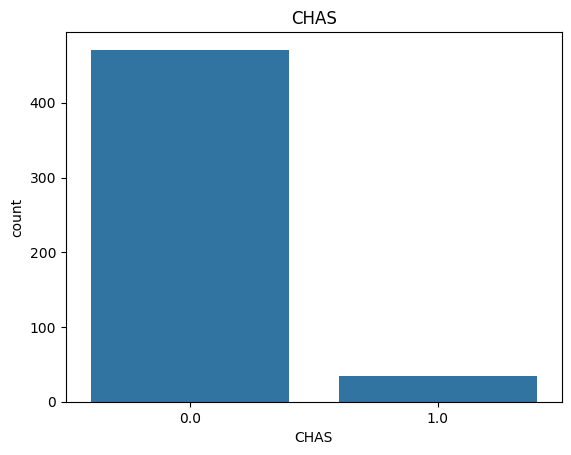

<Figure size 800x600 with 0 Axes>

In [24]:
sns.countplot(x=boston_df['CHAS'])
pyplot.title("CHAS")
pyplot.figure(figsize=(8,6))
pyplot.show()

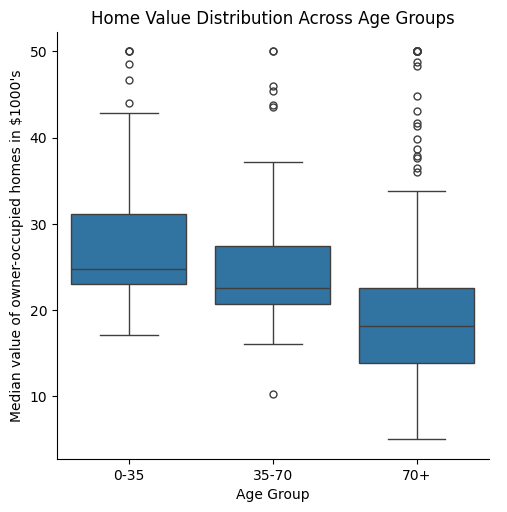

<Figure size 800x600 with 0 Axes>

In [37]:
boston_df['AGE_GROUP'] = pd.cut(boston_df['AGE'], bins=[0, 35, 70, 100], labels=['0-35', '35-70', '70+'])
sns.catplot(x=boston_df['AGE_GROUP'], y=boston_df['MEDV'], kind="box")
pyplot.title("Home Value Distribution Across Age Groups")
pyplot.xlabel("Age Group")
pyplot.ylabel("Median value of owner-occupied homes in $1000's")
pyplot.figure(figsize=(8,6))
pyplot.show()

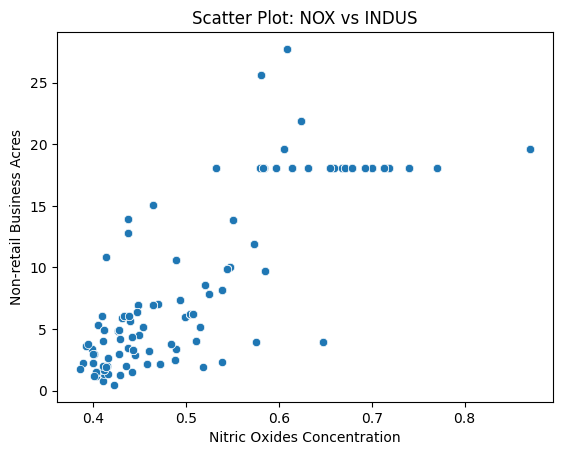

<Figure size 800x600 with 0 Axes>

In [45]:
sns.scatterplot(x=boston_df['NOX'], y=boston_df['INDUS'])
pyplot.title('Scatter Plot: NOX vs INDUS')
pyplot.xlabel('Nitric Oxides Concentration')
pyplot.ylabel('Non-retail Business Acres')
pyplot.figure(figsize=(8,6))
pyplot.show()

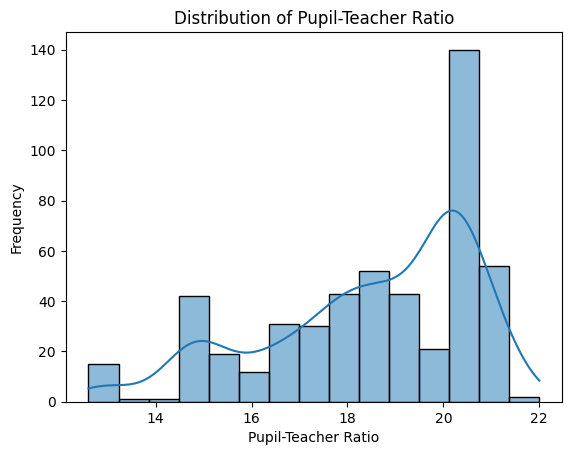

<Figure size 800x600 with 0 Axes>

In [51]:
sns.histplot(boston_df['PTRATIO'], bins=15, kde=True)
pyplot.title('Distribution of Pupil-Teacher Ratio')
pyplot.xlabel('Pupil-Teacher Ratio')
pyplot.ylabel('Frequency')
pyplot.figure(figsize=(8,6))
pyplot.show()

In [54]:
from scipy.stats import ttest_ind

chas1 = boston_df[boston_df['CHAS'] == 1]['MEDV']
chas0 = boston_df[boston_df['CHAS'] == 0]['MEDV']

t_stat, p_val = ttest_ind(chas1, chas0)
print(f"T-test results: t={t_stat}, p={p_val}")


T-test results: t=3.996437466090509, p=7.390623170519905e-05


In [55]:
from scipy.stats import f_oneway

group1 = boston_df[boston_df['AGE_GROUP'] == '0-35']['MEDV']
group2 = boston_df[boston_df['AGE_GROUP'] == '35-70']['MEDV']
group3 = boston_df[boston_df['AGE_GROUP'] == '70+']['MEDV']

anova_stat, anova_p = f_oneway(group1, group2, group3)
print(f"ANOVA results: F={anova_stat}, p={anova_p}")


ANOVA results: F=36.40764999196599, p=1.7105011022702984e-15


In [56]:
from scipy.stats import pearsonr

corr, p = pearsonr(boston_df['NOX'], boston_df['INDUS'])
print(f"Pearson Correlation: r={corr}, p={p}")


Pearson Correlation: r=0.7636514469209192, p=7.913361061210442e-98


In [57]:
import statsmodels.api as sm

X = boston_df[['DIS']]
X = sm.add_constant(X)
y = boston_df['MEDV']

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Fri, 02 May 2025   Prob (F-statistic):           1.21e-08
Time:                        23:17:30   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0